# 6.1. 고전 조화진동자

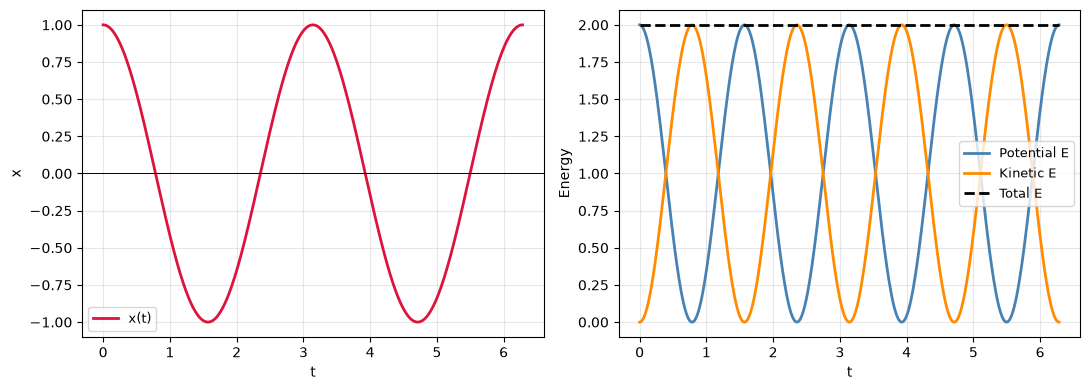

In [1]:
import numpy as np
import matplotlib.pyplot as plt

m, k = 1.0, 4.0
omega = np.sqrt(k / m)
A = 1.0

t = np.linspace(0, 4 * np.pi / omega, 600)
x = A * np.cos(omega * t)
v = -A * omega * np.sin(omega * t)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(t, x, color="crimson", lw=2, label="x(t)")
axes[0].axhline(0, color="black", lw=0.7)
axes[0].set_xlabel("t")
axes[0].set_ylabel("x")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

T = 0.5 * m * v**2
U = 0.5 * k * x**2

axes[1].plot(t, U, color="steelblue", lw=2, label="Potential E")
axes[1].plot(t, T, color="darkorange", lw=2, label="Kinetic E")
axes[1].plot(t, U + T, color="black", lw=2, ls="--", label="Total E")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Energy")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

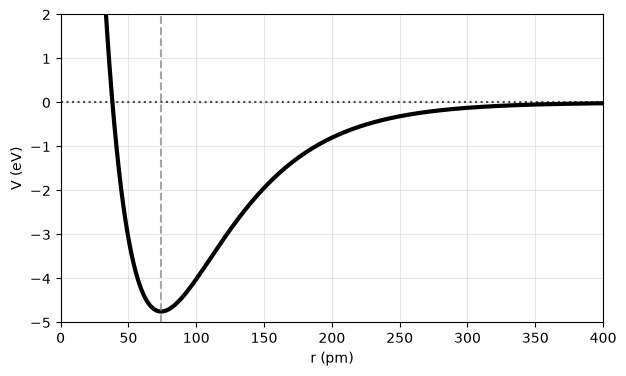

In [2]:
from scipy.constants import e

De, a, re = 4.750 * e, 1.93e10, 74.1e-12
r = np.linspace(0.15e-10, 4.0e-10, 2000)
V = De * (1 - np.exp(-a * (r - re))) ** 2 - De  # 수소 분자의 Morse 근사 퍼텐셜

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r * 1e12, V / e, color="black", lw=3)
ax.axvline(re * 1e12, color="gray", alpha=0.7, ls="--", lw=1.5)
ax.axhline(0, color='black', alpha=0.7, ls=':', lw=1.5)
ax.set_xlim(0, 400)
ax.set_ylim(-5, 2)
ax.set_xlabel("r (pm)")
ax.set_ylabel("V (eV)")
ax.grid(alpha=0.3)

plt.show()

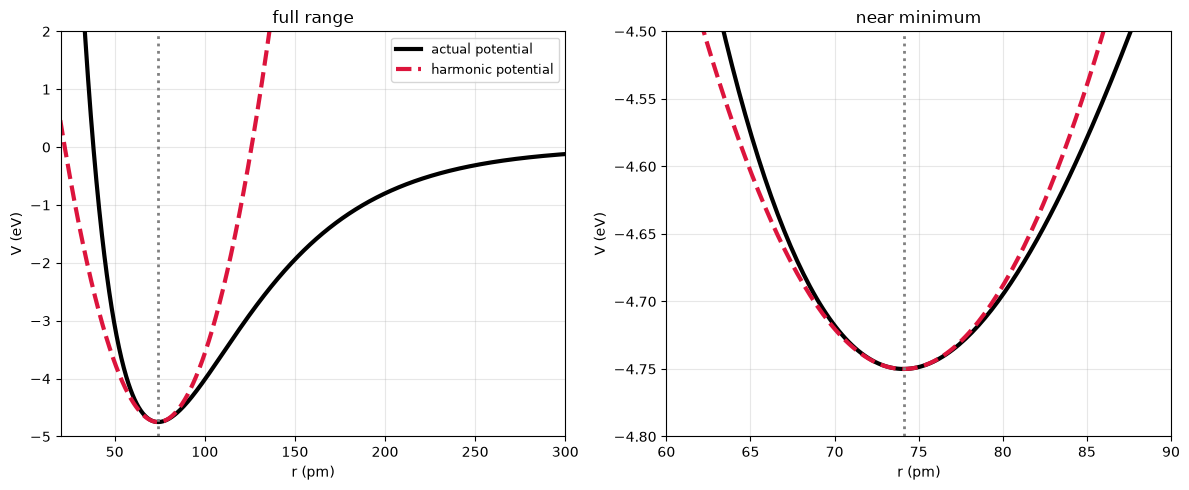

In [3]:
k = 2 * De * a**2
V_harmonic = 0.5 * k * (r - re) ** 2 - De

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (xlim, ylim) in zip(axes, [((20, 300), (-5, 2)), ((60, 90), (-4.8, -4.5))]):
    ax.plot(r * 1e12, V / e, color="black", lw=3, label="actual potential")
    ax.plot(
        r * 1e12,
        V_harmonic / e,
        color="crimson",
        lw=3,
        ls="--",
        label="harmonic potential",
    )
    ax.axvline(re * 1e12, color="gray", ls=":", lw=2)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("r (pm)")
    ax.set_ylabel("V (eV)")
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=9)
axes[0].set_title("full range")
axes[1].set_title("near minimum")
plt.tight_layout()
plt.show()

In [4]:
for tol in [0.01, 0.05, 0.10]:
    ok = np.abs(V_harmonic - V) < tol * De
    print(
        f"오차 {tol * 100:>2.0f}% 이내: r = {r[ok].min() * 1e12:.1f} ~ {r[ok].max() * 1e12:.1f} pm"
    )
print(f"평형 결합 길이 r_e = {re * 1e12:.1f} pm")

오차  1% 이내: r = 63.5 ~ 85.7 pm
오차  5% 이내: r = 56.4 ~ 94.5 pm
오차 10% 이내: r = 52.2 ~ 100.3 pm
평형 결합 길이 r_e = 74.1 pm
